In [219]:
import pandas as pd
import numpy as np
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, math

In [324]:
#df = pd.read_csv('data/04-02-2020.csv')
df = pd.read_csv('data/covid_19_clean_complete.csv')
df.rename(columns={'Date':'Last_Update', 'Long': 'Long_'}, inplace=True)
df['Last_Update'] = pd.to_datetime(df['Last_Update'])
df

,Province/State,Country/Region,Lat,Long_,Last_Update,Confirmed,Deaths,Recovered
0,NaN,Afghanistan,33.000000,65.000000,2020-01-22,0,0,0
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0
...,...,...,...,...,...,...,...,...
29563,NaN,Western Sahara,24.215500,-12.885800,2020-05-12,6,0,6
29564,NaN,Sao Tome and Principe,0.186360,6.613081,2020-05-12,208,5,4
29565,NaN,Yemen,15.552727,48.516388,2020-05-12,65,10,1
29566,NaN,Comoros,-11.645500,43.333300,2020-05-12,11,1,0


In [325]:
df['Last_Update'].unique()

array(['2020-01-22T00:00:00.000000000', '2020-01-23T00:00:00.000000000',
       '2020-01-24T00:00:00.000000000', '2020-01-25T00:00:00.000000000',
       '2020-01-26T00:00:00.000000000', '2020-01-27T00:00:00.000000000',
       '2020-01-28T00:00:00.000000000', '2020-01-29T00:00:00.000000000',
       '2020-01-30T00:00:00.000000000', '2020-01-31T00:00:00.000000000',
       '2020-02-01T00:00:00.000000000', '2020-02-02T00:00:00.000000000',
       '2020-02-03T00:00:00.000000000', '2020-02-04T00:00:00.000000000',
       '2020-02-05T00:00:00.000000000', '2020-02-06T00:00:00.000000000',
       '2020-02-07T00:00:00.000000000', '2020-02-08T00:00:00.000000000',
       '2020-02-09T00:00:00.000000000', '2020-02-10T00:00:00.000000000',
       '2020-02-11T00:00:00.000000000', '2020-02-12T00:00:00.000000000',
       '2020-02-13T00:00:00.000000000', '2020-02-14T00:00:00.000000000',
       '2020-02-15T00:00:00.000000000', '2020-02-16T00:00:00.000000000',
       '2020-02-17T00:00:00.000000000', '2020-02-18

In [329]:
start_time = df['Last_Update'].min()
(df['Last_Update'] - start_time).dt.days.unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111])

In [334]:
#d = {'Lat':'Lat_avg', 'Long_':'Long_avg','Confirmed':'Confirmed_sum', 'Deaths':'Deaths_sum', 'Recovered':'Recovered_sum'}
#df_group = df.groupby(['Last_Update', 'Province_State']).agg({'Lat':'mean', 'Long_':'mean','Confirmed':'sum', 'Deaths':'sum', 'Recovered':'sum'}).rename(columns=d)
#df_group.reset_index(inplace=True)
start_time = df['Last_Update'].min()
df_train = df.copy()
#df_train['hour_diff'] = (df['Last_Update'] - start_time) / np.timedelta64(1, 'd')
df_train['day_diff'] = (df['Last_Update'] - start_time).dt.days

df_train['year'] = df_train['Last_Update'].dt.year
df_train['month'] = df_train['Last_Update'].dt.month
df_train['day'] = df_train['Last_Update'].dt.day
DAY_SHIFT = 2
shift_column_names = []
for i in range(1, DAY_SHIFT + 1):
    confirm_col, deaths_col, recovered_col = 'Confirmed_past{}'.format(i), 'Deaths_past{}'.format(i), 'Recovered_past{}'.format(i)
    df_train[confirm_col] = df['Confirmed'].shift(i)
    df_train[deaths_col] = df['Deaths'].shift(i)
    df_train[recovered_col] = df['Recovered'].shift(i)
    shift_column_names.extend([confirm_col, deaths_col, recovered_col])
df_train.dropna(subset=shift_column_names, inplace=True, axis=0, how='any')
df_train.drop(columns=['Country/Region', 'Province/State', 'Last_Update', 'Deaths', 'Recovered'], inplace=True)
df_train

,Lat,Long_,Confirmed,day_diff,year,month,day,Confirmed_past1,Deaths_past1,Recovered_past1,Confirmed_past2,Deaths_past2,Recovered_past2
2,28.033900,1.659600,0,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
3,42.506300,1.521800,0,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
4,-11.202700,17.873900,0,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
5,17.060800,-61.796400,0,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
6,-38.416100,-63.616700,0,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29563,24.215500,-12.885800,6,111,2020,5,12,194.0,0.0,2.0,1.0,0.0,1.0
29564,0.186360,6.613081,208,111,2020,5,12,6.0,0.0,6.0,194.0,0.0,2.0
29565,15.552727,48.516388,65,111,2020,5,12,208.0,5.0,4.0,6.0,0.0,6.0
29566,-11.645500,43.333300,11,111,2020,5,12,65.0,10.0,1.0,208.0,5.0,4.0


In [313]:
# df_train.dropna(subset=['Lat', 'Long_'], inplace=True)
# df_train

,Lat,Long_,Confirmed,hour_diff,Confirmed_past1,Deaths_past1,Recovered_past1,Confirmed_past2,Deaths_past2,Recovered_past2
2,37.767072,-75.632346,10,948.1,61.0,1.0,0.0,6.0,0.0,0.0
3,43.452658,-116.241552,312,948.1,10.0,0.0,0.0,61.0,1.0,0.0
4,41.330756,-94.471059,1,948.1,312.0,3.0,0.0,10.0,0.0,0.0
5,40.190586,-92.600782,6,948.1,1.0,0.0,0.0,312.0,3.0,0.0
6,35.884942,-94.658593,9,948.1,6.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2563,6.423800,-66.589700,146,948.1,205.0,2.0,25.0,350.0,4.0,62.0
2564,14.058324,108.277199,233,948.1,146.0,5.0,43.0,205.0,2.0,25.0
2565,31.952200,35.233200,161,948.1,233.0,0.0,75.0,146.0,5.0,43.0
2566,-13.133897,27.849332,39,948.1,161.0,1.0,18.0,233.0,0.0,75.0


In [336]:
y_label = 'Confirmed'
df_y = df_train[y_label]
df_train.drop(columns=[y_label], inplace=True)
df_train

,Lat,Long_,day_diff,year,month,day,Confirmed_past1,Deaths_past1,Recovered_past1,Confirmed_past2,Deaths_past2,Recovered_past2
2,28.033900,1.659600,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
3,42.506300,1.521800,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
4,-11.202700,17.873900,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
5,17.060800,-61.796400,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
6,-38.416100,-63.616700,0,2020,1,22,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
29563,24.215500,-12.885800,111,2020,5,12,194.0,0.0,2.0,1.0,0.0,1.0
29564,0.186360,6.613081,111,2020,5,12,6.0,0.0,6.0,194.0,0.0,2.0
29565,15.552727,48.516388,111,2020,5,12,208.0,5.0,4.0,6.0,0.0,6.0
29566,-11.645500,43.333300,111,2020,5,12,65.0,10.0,1.0,208.0,5.0,4.0


In [58]:
# # union all datasets
# input_folder = 'data'
# df = pd.read_csv('data/02-27-2020.csv')
# columns = df.columns
# for file_name in os.listdir(input_folder)[1:]:
#     _df = pd.read_csv('data/{}'.format(file_name))
#     _df = _df.rename({
#         'Province_State': 'Province/State',
#         'Country_Region': 'Country/Region',
#         'Last_Update': 'Last Update'}, axis=1)[columns.tolist()]
#     _df['Last Update'] = pd.to_datetime(_df['Last Update'])
#     df = pd.concat([df, _df])
# df['Last Update'] = pd.to_datetime(df['Last Update'])
# df.fillna('missing', inplace=True)
# df['Country/Region'].replace(['Mainland China'], 'China', inplace=True)
# df['Country/Region'].replace(['United Kingdom'], 'UK', inplace=True)
# df['year'] = df['Last Update'].dt.year
# df['month'] = df['Last Update'].dt.month
# df['day'] = df['Last Update'].dt.day
# ctg_cols = ['Country/Region', 'Province/State']
# df_dummy = pd.get_dummies(df, columns=ctg_cols)
# y_label = 'Confirmed'
# df_y = df_dummy[y_label]
# df_dummy.drop(columns=['Last Update', 'Deaths', 'Recovered', y_label], inplace=True)


In [337]:
num_pipeline = Pipeline([('standard_scaler', StandardScaler())])
df_train_normed = df_train.copy()
df_train_normed[df_train_normed.columns] = num_pipeline.fit_transform(df_train[df_train.columns])
x_train, x_test, y_train, y_test = train_test_split(df_train_normed, df_y, test_size=0.2, random_state=1)
df_train_normed

,Lat,Long_,day_diff,year,month,day,Confirmed_past1,Deaths_past1,Recovered_past1,Confirmed_past2,Deaths_past2,Recovered_past2
2,0.269073,-0.301228,-1.716884,0.0,-1.786320,0.715042,-0.108459,-0.103836,-0.132476,-0.108459,-0.103836,-0.132476
3,0.853719,-0.303186,-1.716884,0.0,-1.786320,0.715042,-0.108459,-0.103836,-0.132476,-0.108459,-0.103836,-0.132476
4,-1.315980,-0.070841,-1.716884,0.0,-1.786320,0.715042,-0.108459,-0.103836,-0.132476,-0.108459,-0.103836,-0.132476
5,-0.174210,-1.202867,-1.716884,0.0,-1.786320,0.715042,-0.108459,-0.103836,-0.132476,-0.108459,-0.103836,-0.132476
6,-2.415328,-1.228731,-1.716884,0.0,-1.786320,0.715042,-0.108459,-0.103836,-0.132476,-0.108459,-0.103836,-0.132476
...,...,...,...,...,...,...,...,...,...,...,...,...
29563,0.114820,-0.507902,1.716651,0.0,1.708079,-0.389500,-0.103244,-0.103836,-0.132246,-0.108433,-0.103836,-0.132361
29564,-0.855892,-0.230845,1.716651,0.0,1.708079,-0.389500,-0.108298,-0.103836,-0.131785,-0.103244,-0.103836,-0.132246
29565,-0.235132,0.364554,1.716651,0.0,1.708079,-0.389500,-0.102868,-0.101898,-0.132015,-0.108298,-0.103836,-0.131785
29566,-1.333867,0.290909,1.716651,0.0,1.708079,-0.389500,-0.106712,-0.099961,-0.132361,-0.102868,-0.101898,-0.132015


In [241]:
x_train

,Lat,Long_,hour_diff,year,month,day
2486,-0.966291,2.239217,0.059951,0.0,0.068781,-0.066185
924,-1.439256,-1.839438,0.059951,0.0,0.068781,-0.066185
1583,0.004070,-0.147413,0.059951,0.0,0.068781,-0.066185
1225,0.396710,-0.111979,0.059951,0.0,0.068781,-0.066185
2507,-0.788668,3.799486,0.059951,0.0,0.068781,-0.066185
...,...,...,...,...,...,...
960,0.422161,-0.003070,0.059951,0.0,0.068781,-0.066185
905,0.037454,-0.021385,0.059951,0.0,0.068781,-0.066185
1096,0.757940,0.229366,0.059951,0.0,0.068781,-0.066185
235,-0.534460,-0.447539,0.059951,0.0,0.068781,-0.066185


Keras model constructed
Train on 23652 samples, validate on 5914 samples
Epoch 1/20
23652/23652 [==============================] - 25s 1ms/step - loss: 3818.9438 - coeff_determination: -0.0112 - val_loss: 4528.1313 - val_coeff_determination: -0.0079
Epoch 2/20
23652/23652 [==============================] - 13s 564us/step - loss: 3803.7959 - coeff_determination: -0.1103 - val_loss: 4514.6373 - val_coeff_determination: -0.0019
Epoch 3/20
23652/23652 [==============================] - 13s 551us/step - loss: 3794.8361 - coeff_determination: -0.0798 - val_loss: 4490.7001 - val_coeff_determination: -0.0679
Epoch 4/20
23652/23652 [==============================] - 14s 581us/step - loss: 3789.5898 - coeff_determination: -0.2862 - val_loss: 4496.9903 - val_coeff_determination: -0.0948
Epoch 5/20
23652/23652 [==============================] - 16s 691us/step - loss: 3789.2873 - coeff_determination: -0.1438 - val_loss: 4492.5649 - val_coeff_determination: 0.0208
Epoch 6/20
23652/23652 [===========

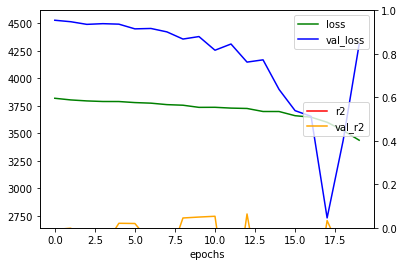

In [340]:
def coeff_determination(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

def create_keras_model(optimizer='adam', neuron=50, init='lecun_normal', act_alpha=0.01):
    model_sequences = [
        keras.layers.Dense(units=neuron, kernel_initializer=init, 
                           #activation='relu',
                           input_shape=x_train.shape[1:]
                          ),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=act_alpha),
        keras.layers.Dropout(0.2)
    ]

    for i in range(3):
        model_sequences.append(keras.layers.Dense(units=neuron, kernel_initializer=init,
                                                  #activation='relu',
                                                  input_shape=x_train.shape[1:]))
        model_sequences.append(keras.layers.BatchNormalization())
        model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))
        model_sequences.append(keras.layers.Dropout(0.2))

    model_sequences.append(Dense(units=1, name='score_output',
                                 #activation='relu'
                                ))
    model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    nn_model = keras.models.Sequential(model_sequences)
    nn_model.compile(optimizer=optimizer, loss='mae', metrics=[coeff_determination])
    return nn_model

# lr_schedule = keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=1e-2,
#     decay_steps=1000,
#     decay_rate=0.9)
optimizer = keras.optimizers.Adamax(lr=0.3)
nn_model = create_keras_model(optimizer=optimizer, neuron=500, init='lecun_uniform', act_alpha=0.05)
print("Keras model constructed")
#early_stopping_cb = EarlyStopping(patience=20)
history = nn_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, callbacks=[], verbose=1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('epochs')
df_history = pd.DataFrame(history.history)
#ax1.set_ylabel('exp', color=color)
ax1.plot(df_history.index, df_history['loss'], color='green', label="loss")
ax1.plot(df_history.index, df_history['val_loss'], color='blue', label="val_loss")
ax1.tick_params(axis='y')
ax1.legend(loc="upper right")
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax2.plot(df_history.index, df_history['coeff_determination'], color='red', label="r2")
ax2.plot(df_history.index, df_history['val_coeff_determination'], color='orange', label="val_r2")
ax2.tick_params(axis='y')
ax2.set_ylim([0, 1])
ax2.legend(loc="center right")

#fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()